In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import torch.nn as nn
from src.preprocess import load_and_clean_data, split_data
from src.dataset import build_vocabulary, load_glove, create_dataloaders
from src.model import TextCNN
from src.train import train_model
from src.evaluate import evaluate_model, get_predictions, plot_confusion_matrix, plot_training_curves

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Cargar y limpiar datos ───────────────────────────────────────────────
df = load_and_clean_data("WELFake_clean.csv")

# ── Split train/val/test ─────────────────────────────────────────────────
train_df, val_df, test_df = split_data(df)

X_train = train_df["clean_text"].tolist()
y_train = train_df["label"].tolist()
X_val   = val_df["clean_text"].tolist()
y_val   = val_df["label"].tolist()
X_test  = test_df["clean_text"].tolist()
y_test  = test_df["label"].tolist()

# ── Vocabulario (solo con train) ─────────────────────────────────────────
word2idx = build_vocabulary(X_train, max_vocab=20000)
vocab_size = len(word2idx)
print(f"Vocabulario: {vocab_size} palabras")

# ── DataLoaders ──────────────────────────────────────────────────────────
train_loader, val_loader, test_loader = create_dataloaders(
    train_data=(X_train, y_train),
    val_data=(X_val, y_val),
    test_data=(X_test, y_test),
    word2idx=word2idx,
    batch_size=64,
    max_len=200
)

# ── GloVe ────────────────────────────────────────────────────────────────
embedding_matrix = load_glove("glove.6B.50d.txt", word2idx, embed_dim=50)

# ── Modelo Random (embeddings aleatorios) ────────────────────────────────
model_random = TextCNN(
    vocab_size=vocab_size,
    embed_dim=50,
    num_filters=100,
    kernel_sizes=[3, 4, 5],
    dropout=0.5,
    pretrained_embeddings=None
).to(device)

# ── Modelo GloVe (embeddings preentrenados) ──────────────────────────────
model_glove = TextCNN(
    vocab_size=vocab_size,
    embed_dim=50,
    num_filters=100,
    kernel_sizes=[3, 4, 5],
    dropout=0.5,
    pretrained_embeddings=embedding_matrix
).to(device)

print(f"\nmodel_random: {sum(p.numel() for p in model_random.parameters()):,} parámetros")
print(f"model_glove:  {sum(p.numel() for p in model_glove.parameters()):,} parámetros")

Device: cpu
[INFO] Se eliminaron 395 filas duplicadas.
[INFO] Dataset final: 62661 filas.
[INFO] Train: 50128 | Val: 6266 | Test: 6267
Vocabulario: 20002 palabras
DataLoaders creados:
  Entrenamiento: 50,128 muestras -> 784 batches
  Validacion:    6,266 muestras -> 98 batches
  Prueba:        6,267 muestras -> 98 batches
  Batch size: 64 | Max len: 200
GloVe cargado: 18,192 / 20,002 palabras encontradas (91.0% de cobertura)

model_random: 1,060,701 parámetros
model_glove:  1,060,701 parámetros


In [2]:
criterion = torch.nn.BCEWithLogitsLoss()

# ── Entrenar modelo Random ───────────────────────────────────────────────
print("="*50)
print("ENTRENANDO: TextCNN con embeddings ALEATORIOS")
print("="*50)

optimizer_random = torch.optim.Adam(model_random.parameters(), lr=1e-3)

history_random = train_model(
    model=model_random,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_random,
    criterion=criterion,
    device=device,
    num_epochs=10,
    patience=3
)

# ── Entrenar modelo GloVe ────────────────────────────────────────────────
print("\n" + "="*50)
print("ENTRENANDO: TextCNN con embeddings GLOVE")
print("="*50)

optimizer_glove = torch.optim.Adam(model_glove.parameters(), lr=1e-3)

history_glove = train_model(
    model=model_glove,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_glove,
    criterion=criterion,
    device=device,
    num_epochs=10,
    patience=3
)

ENTRENANDO: TextCNN con embeddings ALEATORIOS
Epoch 01/10 | Train Loss: 0.3327  Train F1: 0.8217 | Val Loss: 0.1562  Val F1: 0.9309
Epoch 02/10 | Train Loss: 0.1702  Train F1: 0.9234 | Val Loss: 0.1235  Val F1: 0.9464
Epoch 03/10 | Train Loss: 0.1373  Train F1: 0.9400 | Val Loss: 0.1058  Val F1: 0.9549
Epoch 04/10 | Train Loss: 0.1085  Train F1: 0.9522 | Val Loss: 0.0974  Val F1: 0.9568
Epoch 05/10 | Train Loss: 0.0876  Train F1: 0.9625 | Val Loss: 0.0909  Val F1: 0.9613
Epoch 06/10 | Train Loss: 0.0706  Train F1: 0.9699 | Val Loss: 0.0880  Val F1: 0.9618
Epoch 07/10 | Train Loss: 0.0572  Train F1: 0.9763 | Val Loss: 0.0893  Val F1: 0.9627
Epoch 08/10 | Train Loss: 0.0441  Train F1: 0.9819 | Val Loss: 0.0976  Val F1: 0.9623
Epoch 09/10 | Train Loss: 0.0356  Train F1: 0.9865 | Val Loss: 0.1046  Val F1: 0.9608
Epoch 10/10 | Train Loss: 0.0257  Train F1: 0.9900 | Val Loss: 0.1070  Val F1: 0.9644

ENTRENANDO: TextCNN con embeddings GLOVE
Epoch 01/10 | Train Loss: 0.2444  Train F1: 0.8770 |

Curvas: TextCNN Random


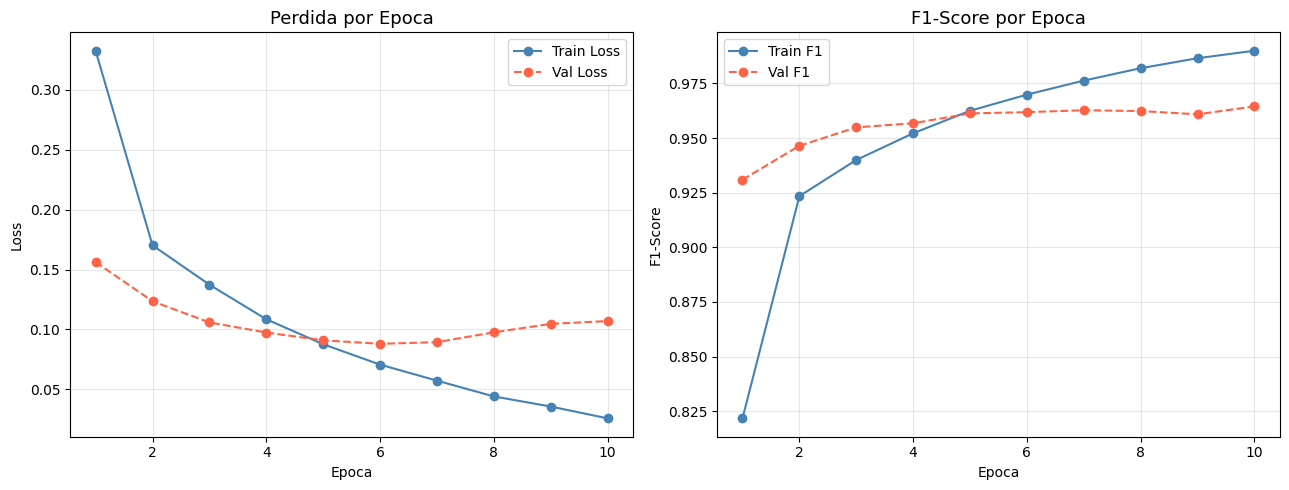

Curvas: TextCNN GloVe


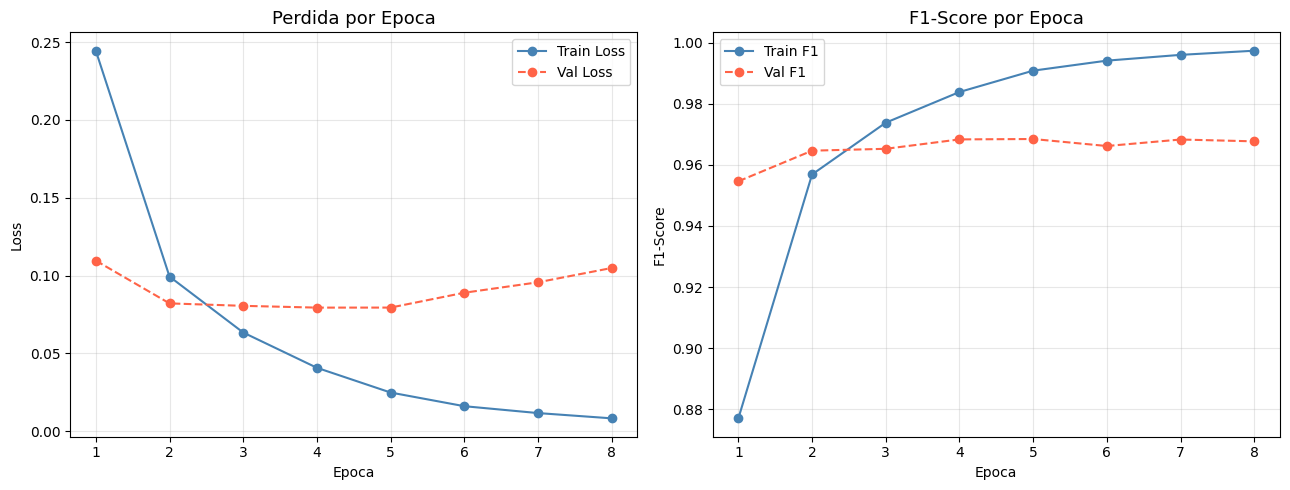


MÉTRICA            Random        GloVe
loss               0.1106       0.0862
accuracy           0.9679       0.9716
f1                 0.9642       0.9683
precision          0.9633       0.9659
recall             0.9651       0.9708


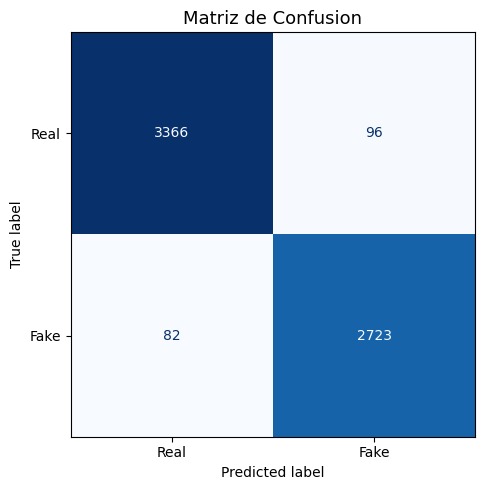

In [3]:
# ── Reto 4.2 — Curvas de entrenamiento ──────────────────────────────────
print("Curvas: TextCNN Random")
plot_training_curves(history_random)

print("Curvas: TextCNN GloVe")
plot_training_curves(history_glove)

# ── Reto 4.3 — Evaluación en test ───────────────────────────────────────
criterion = torch.nn.BCEWithLogitsLoss()

metrics_random = evaluate_model(model_random, test_loader, criterion, device)
metrics_glove  = evaluate_model(model_glove,  test_loader, criterion, device)

print("\n" + "="*55)
print(f"{'MÉTRICA':<12} {'Random':>12} {'GloVe':>12}")
print("="*55)
for key in ["loss", "accuracy", "f1", "precision", "recall"]:
    print(f"{key:<12} {metrics_random[key]:>12.4f} {metrics_glove[key]:>12.4f}")
print("="*55)

# ── Matriz de confusión del mejor modelo (GloVe) ─────────────────────────
y_true, y_pred, _ = get_predictions(model_glove, test_loader, device)
plot_confusion_matrix(y_true, y_pred, labels=["Real", "Fake"])

In [6]:
import pandas as pd

tabla = pd.DataFrame({
    "Modelo": [
        "Naive Bayes",
        "Logistic Regression",
        "SVM",
        "Decision Tree",
        "TextCNN Random",
        "TextCNN GloVe"
    ],
    "Representación": [
        "BoW", "BoW", "BoW", "BoW",
        "Embeddings aleatorios",
        "GloVe 6B 50d"
    ],
    "Accuracy": [0.9170, 0.9777, 0.9761, 0.9701, 0.9679, 0.9716],
    "F1":       [0.9160, 0.9775, 0.9759, 0.9698, 0.9642, 0.9683],
    "Precision":["—",    "—",    "—",    "—",    0.9633, 0.9659],
    "Recall":   ["—",    "—",    "—",    "—",    0.9651, 0.9708],
    "Loss":     ["—",    "—",    "—",    "—",    0.1106, 0.0862],
})

print(tabla.to_string(index=False))
tabla.to_csv("comparacion_final_reto4.csv", index=False)
print("\n✅ Guardado en comparacion_final_reto4.csv")

             Modelo        Representación  Accuracy     F1 Precision  Recall    Loss
        Naive Bayes                   BoW    0.9170 0.9160         —       —       —
Logistic Regression                   BoW    0.9777 0.9775         —       —       —
                SVM                   BoW    0.9761 0.9759         —       —       —
      Decision Tree                   BoW    0.9701 0.9698         —       —       —
     TextCNN Random Embeddings aleatorios    0.9679 0.9642    0.9633  0.9651  0.1106
      TextCNN GloVe          GloVe 6B 50d    0.9716 0.9683    0.9659  0.9708  0.0862

✅ Guardado en comparacion_final_reto4.csv


## Reflexión: ¿Los embeddings preentrenados convergieron más rápido? ¿Por qué?

**Sí.** TextCNN con GloVe convergió en **8 épocas** (early stopping),
mientras que el modelo Random necesitó las **10 épocas completas**.

Además, GloVe arrancó con Val F1: **0.9546** desde la época 1,
mientras que Random empezó en **0.9309** — una diferencia de 0.024.

### ¿Por qué?

GloVe ya tiene información semántica preentrenada con miles de millones
de palabras del internet. Palabras como *"fake"*, *"false"*, *"government"*
ya tienen vectores que capturan su significado y relaciones entre ellas.
El modelo no necesita aprender eso desde cero — solo